In [1]:
# python v3.11.8
# import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

# set directory, import data, drop undefined
os.chdir('C:\\Users\\Sam Anderson\\Desktop\\pellegrini_lab_research\\raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) # mm39
data = data.dropna()

# referring to the point in the data where methylation and phenotype data diverge
sep=55

# seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [35]:
# filter trait data to minimize colinearity
filter = 0.70
f_trait_data = quality_filter(trait_data, filter)

print(f'{f_trait_data.shape[0]} traits')

24 traits


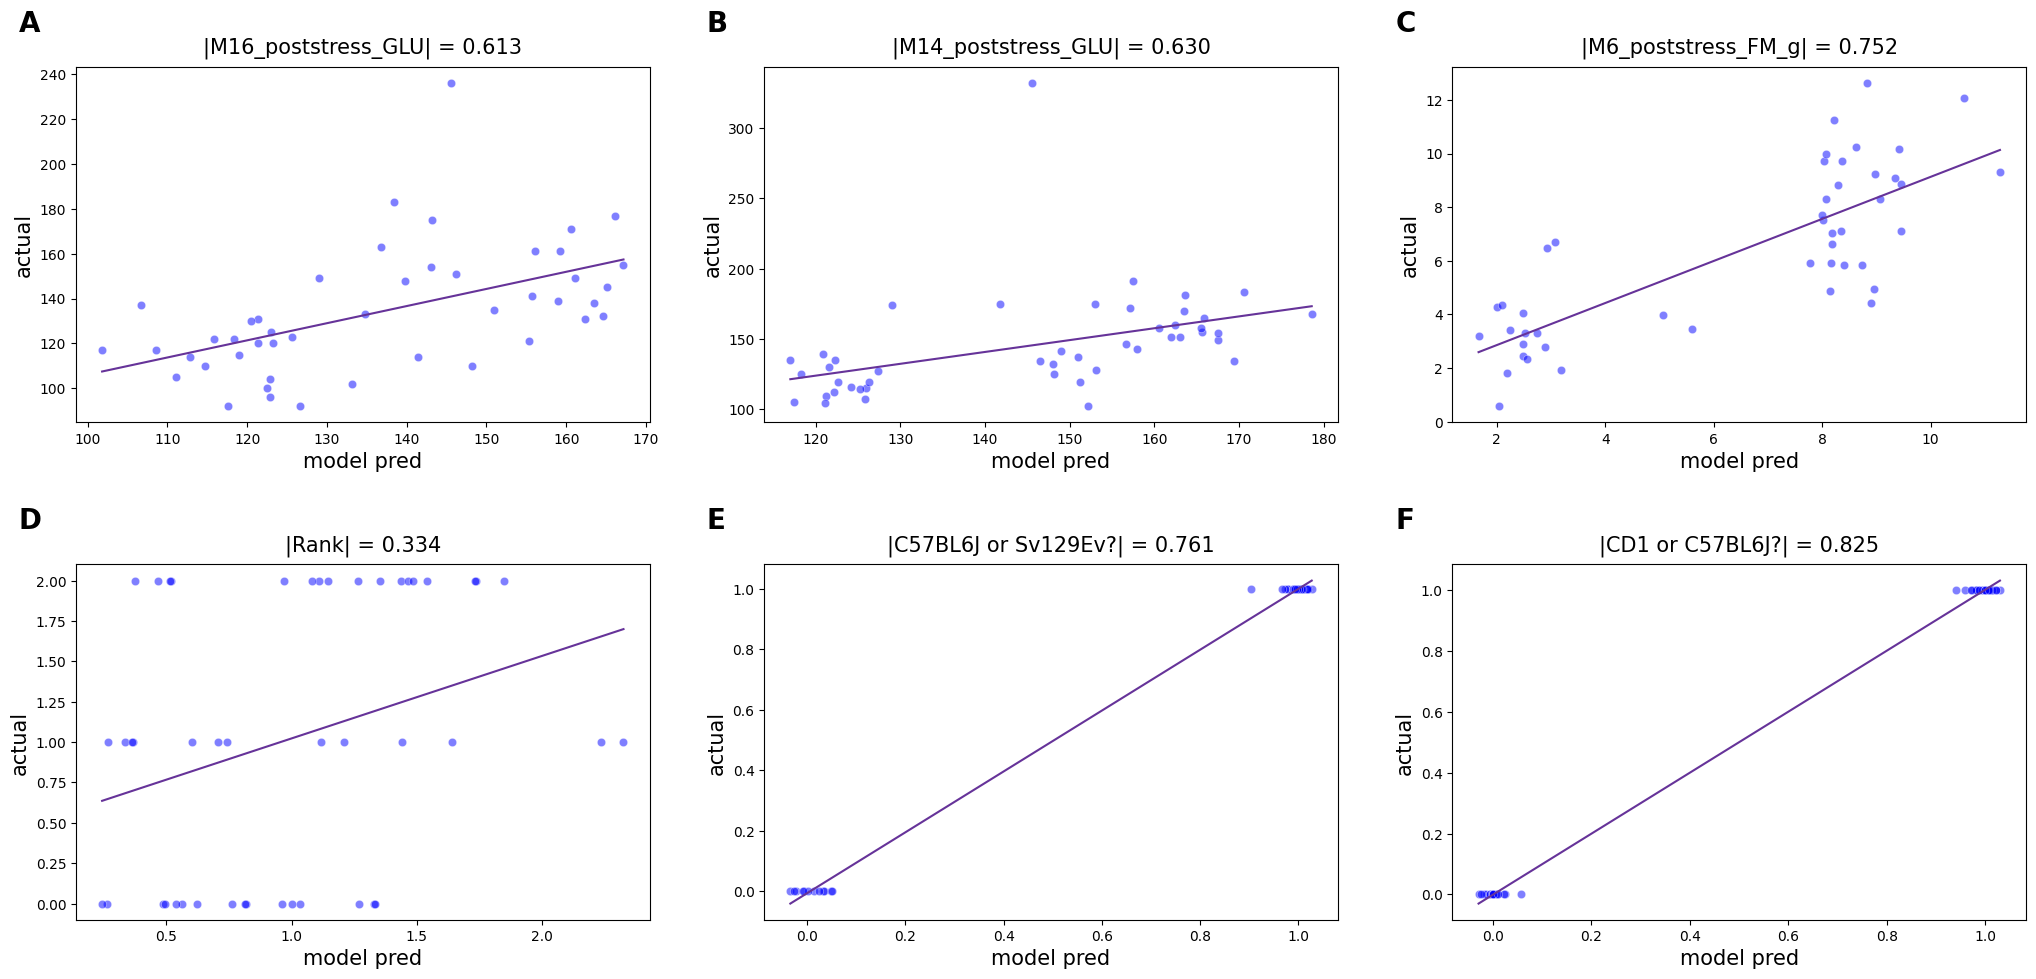

In [37]:
# generate pseudoinversion plots
trait_thresh = 0.60
probe_thresh = 0.50
pinv_dropmin(f_trait_data, meth_data, trait_thresh, 
             find_meth=False, probe_thresh=probe_thresh);

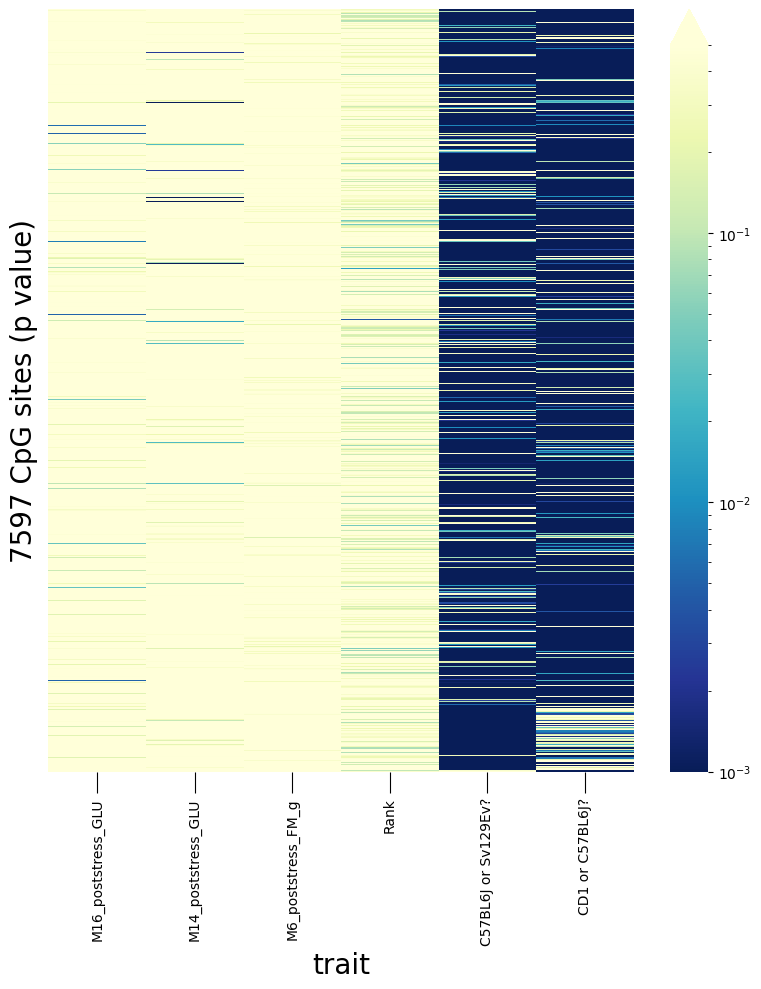

In [10]:
# generate heatmap of probe/trait MMR AdjP values
probe_thresh = 0.50
trait_vals, trait_pvals = pinv_dropmin(f_trait_data, meth_data, trait_thresh, 
                                            find_meth=True, plot_results=True, 
                                            probe_thresh=probe_thresh);

In [11]:
# identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

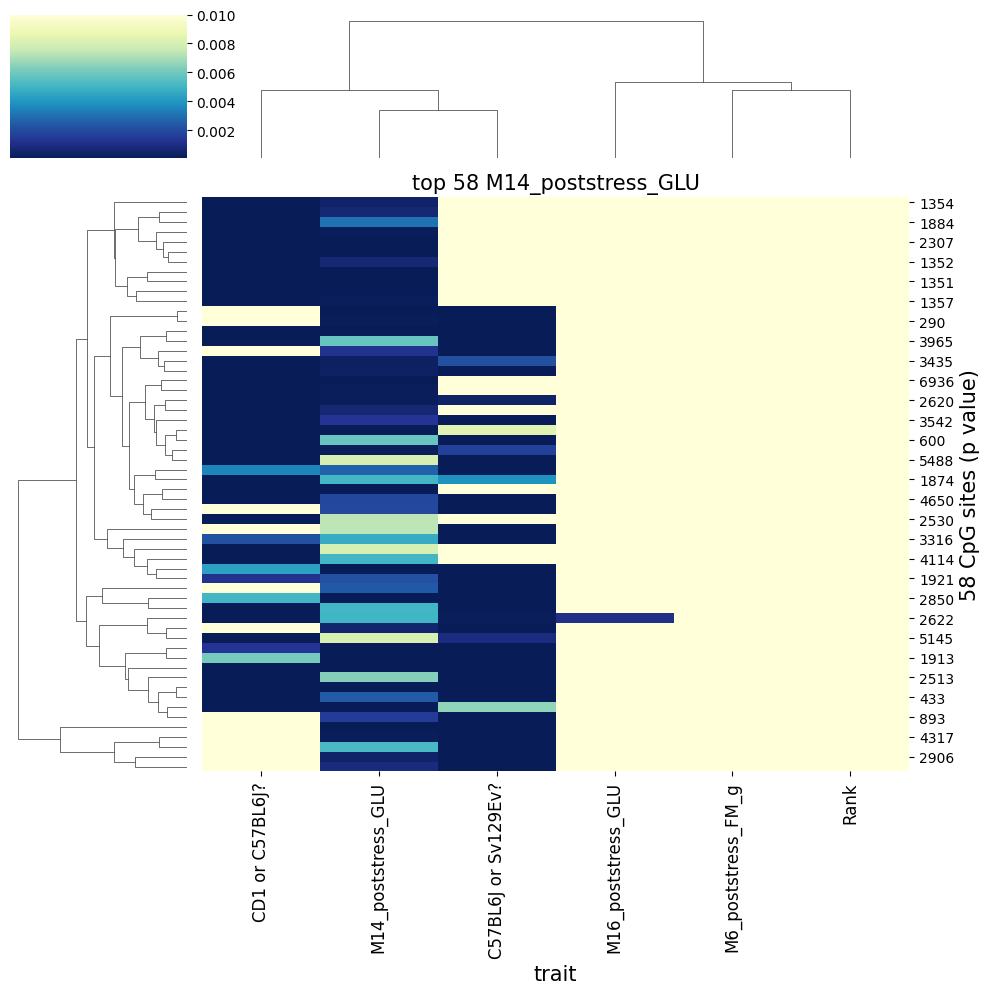

In [12]:
# generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M14_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [13]:
# find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

trait_vals.to_excel('C:\\Users\\Sam Anderson\\Desktop\\pellegrini_lab_research\\model_outputs\\pseudoinverse_probes_filtered.xlsx')
trait_vals

,M16_poststress_GLU_pval,M16_poststress_GLU_coef,M14_poststress_GLU_pval,M14_poststress_GLU_coef,M6_poststress_FM_g_pval,M6_poststress_FM_g_coef,Rank_pval,Rank_coef,C57BL6J or Sv129Ev?_pval,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
cg06259996_TC21,0.442692,0.000156,0.930003,-0.000045,0.731469,-0.000922,0.819510,-0.001136,8.149909e-11,-0.062170,3.443799e-09,-0.053636,chr13,78346406,78346408,chr13,78198287.0,78198289.0,"Nr2f1 (+1,469), Pou5f2 (+173,386)"
cg11548411_BC21,0.177624,0.000262,0.613271,-0.000113,0.817277,-0.000754,0.935813,0.000510,6.893045e-12,-0.080537,6.633491e-11,-0.074531,chr19,45290832,45290834,chr19,45302393.0,45302395.0,"Lbx1 (-66,582), Btrc (-61,357)"
cg28108944_BC11,0.997607,-0.000003,0.999171,0.000003,0.832635,0.000933,0.802491,0.001897,1.080646e-05,0.054450,7.563034e-13,0.117291,chr12,20109465,20109467,chr12,20059464.0,20059466.0,"Gm10479 (-356,473)"
cg28108956_TC21,0.627037,0.000183,0.980019,-0.000033,0.702460,-0.001630,0.366508,-0.005738,1.888645e-06,0.062226,4.791962e-13,0.122918,chr6,40524504,40524506,chr6,40547570.0,40547572.0,"Prss37 (-28,063), Olfr461 (+7,479)"
cg28108957_BC21,0.512814,0.000204,0.984136,-0.000029,0.663451,-0.001677,0.288598,-0.006036,2.566893e-04,0.040966,1.445754e-12,0.107946,chr17,49754778,49754780,chr17,49447750.0,49447752.0,"Mocs1 (+19,341), Daam2 (+116,592)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343211_TC11,0.736464,-0.000410,0.191447,0.000776,0.636405,-0.006211,0.565736,-0.012092,4.420755e-12,0.339009,2.748306e-04,-0.136776,chrY,90737336,90737338,chrY,90726067.0,90726069.0,"Gm21996 (-980,536), Erdr1 (-58,670)"
cg48343225_BC11,0.221863,-0.000816,0.996391,0.000022,0.382183,-0.008550,0.155553,-0.021734,2.906974e-15,0.357140,9.939522e-02,-0.047429,chrY,90738474,90738476,chrY,90727205.0,90727207.0,"Gm21996 (-981,674), Erdr1 (-57,532)"
cg48343290_TC21,0.679611,0.000613,0.985188,0.000116,0.844473,-0.003479,0.528672,0.016420,5.354515e-12,0.421989,1.530760e-01,-0.063626,chrY,90742237,90742239,chrY,90730968.0,90730970.0,"Gm21996 (-985,437), Erdr1 (-53,769)"
cg48343860_TC21,0.741660,-0.000584,0.625083,0.000667,0.660268,-0.008165,0.996385,-0.000176,2.078854e-05,0.236036,2.836897e-13,0.549683,chrY,90771588,90771590,chrY,90760319.0,90760321.0,"Erdr1 (-24,418)"


In [14]:
# get unfiltered probe set using the previously selected traits

trait_data_2 = pd.DataFrame()
for column in trait_pvals: # for each of the final traits
    trait_data_2[column] = trait_data.T[column]

trait_data_2 = trait_data_2.T

trait_vals, trait_pvals = pinv_dropmin(trait_data_2, meth_data, 0.01, 
                                        find_meth=True, plot_results=False);

In [15]:
# find gene associations of probes via GREAT

probe_df = get_pos(trait_vals, mm39_data)

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']
trait_vals.to_excel('C:\\Users\\Sam Anderson\\Desktop\\pellegrini_lab_research\\model_outputs\\pseudoinverse_probes_unfiltered.xlsx')

In [16]:
# remove insignificant p values
trait_vals_no_insig = trait_vals.copy()
numeric_cols = trait_vals_no_insig.select_dtypes(include=[np.number]).columns
trait_vals_no_insig[numeric_cols] = trait_vals_no_insig[numeric_cols].applymap(lambda x: np.nan if x > 0.01 else x)

# restore position info
trait_vals_no_insig['pos_mm10'] = trait_vals['pos_mm10']
trait_vals_no_insig['end_mm10'] = trait_vals['end_mm10']

trait_vals_no_insig

,M16_poststress_GLU_pval,M16_poststress_GLU_coef,M14_poststress_GLU_pval,M14_poststress_GLU_coef,M6_poststress_FM_g_pval,M6_poststress_FM_g_coef,Rank_pval,Rank_coef,C57BL6J or Sv129Ev?_pval,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
cg00101675_BC21,NaN,0.000081,NaN,-0.000117,NaN,-0.002601,NaN,-0.011280,NaN,-0.040013,0.003370,-0.049953,chr12,NaN,NaN,chr12,75515718.0,75515720.0,"Gphb5 (-98,938), Ppp2r5e (+80,481)"
cg00116289_BC21,NaN,0.000162,NaN,-0.000047,NaN,-0.001403,NaN,-0.003272,4.935859e-03,-0.046349,0.004475,-0.047011,chr15,NaN,NaN,chr15,12170849.0,12170851.0,"Mtmr12 (-34,178), Zfr (+53,019)"
cg00211372_TC21,NaN,-0.000453,NaN,-0.000201,NaN,-0.001107,NaN,-0.005368,NaN,0.006388,NaN,-0.001168,chrX,NaN,NaN,chrX,57387383.0,57387385.0,"Arhgef6 (-48,655), Rbmx (+5,652)"
cg00531009_BC21,NaN,0.000168,NaN,0.000017,NaN,-0.002317,NaN,-0.004608,6.953705e-03,-0.026317,0.000050,-0.043177,chr19,NaN,NaN,chr19,6375936.0,6375938.0,"Pygm (-8,462), Sf1 (+12,247)"
cg00747726_TC21,NaN,0.000446,NaN,0.000346,NaN,-0.001882,NaN,-0.020792,NaN,0.008920,NaN,NaN,chr18,NaN,NaN,chr18,35572741.0,35572743.0,"Paip2 (-25,907), Matr3 (+10,584)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48344138_TC21,NaN,0.000058,NaN,0.000045,NaN,0.000573,NaN,-0.014087,NaN,-0.005806,NaN,-0.055688,chrY,NaN,NaN,chrY,90808022.0,90808024.0,"Erdr1 (+23,285)"
cg48344145_TC21,NaN,0.000298,NaN,0.000149,NaN,-0.008820,NaN,-0.008844,NaN,NaN,NaN,NaN,chrY,NaN,NaN,chrY,90808868.0,90808870.0,"Erdr1 (+24,131)"
cg48344158_BC11,NaN,-0.000021,NaN,-0.000073,NaN,0.000317,NaN,-0.005254,NaN,-0.029972,0.000119,-0.049525,chrY,NaN,NaN,chrY,90809535.0,90809537.0,"Erdr1 (+24,798)"
cg48344197_BC21,NaN,0.000352,NaN,0.000455,NaN,-0.007858,NaN,-0.002377,NaN,0.009264,NaN,-0.080556,chrY,NaN,NaN,chrY,90813404.0,90813406.0,"Erdr1 (+28,667)"


No valid probes, skipping trait M16_poststress_GLU_pval
No valid probes, skipping trait M6_poststress_FM_g_pval
No valid probes, skipping trait Rank_pval


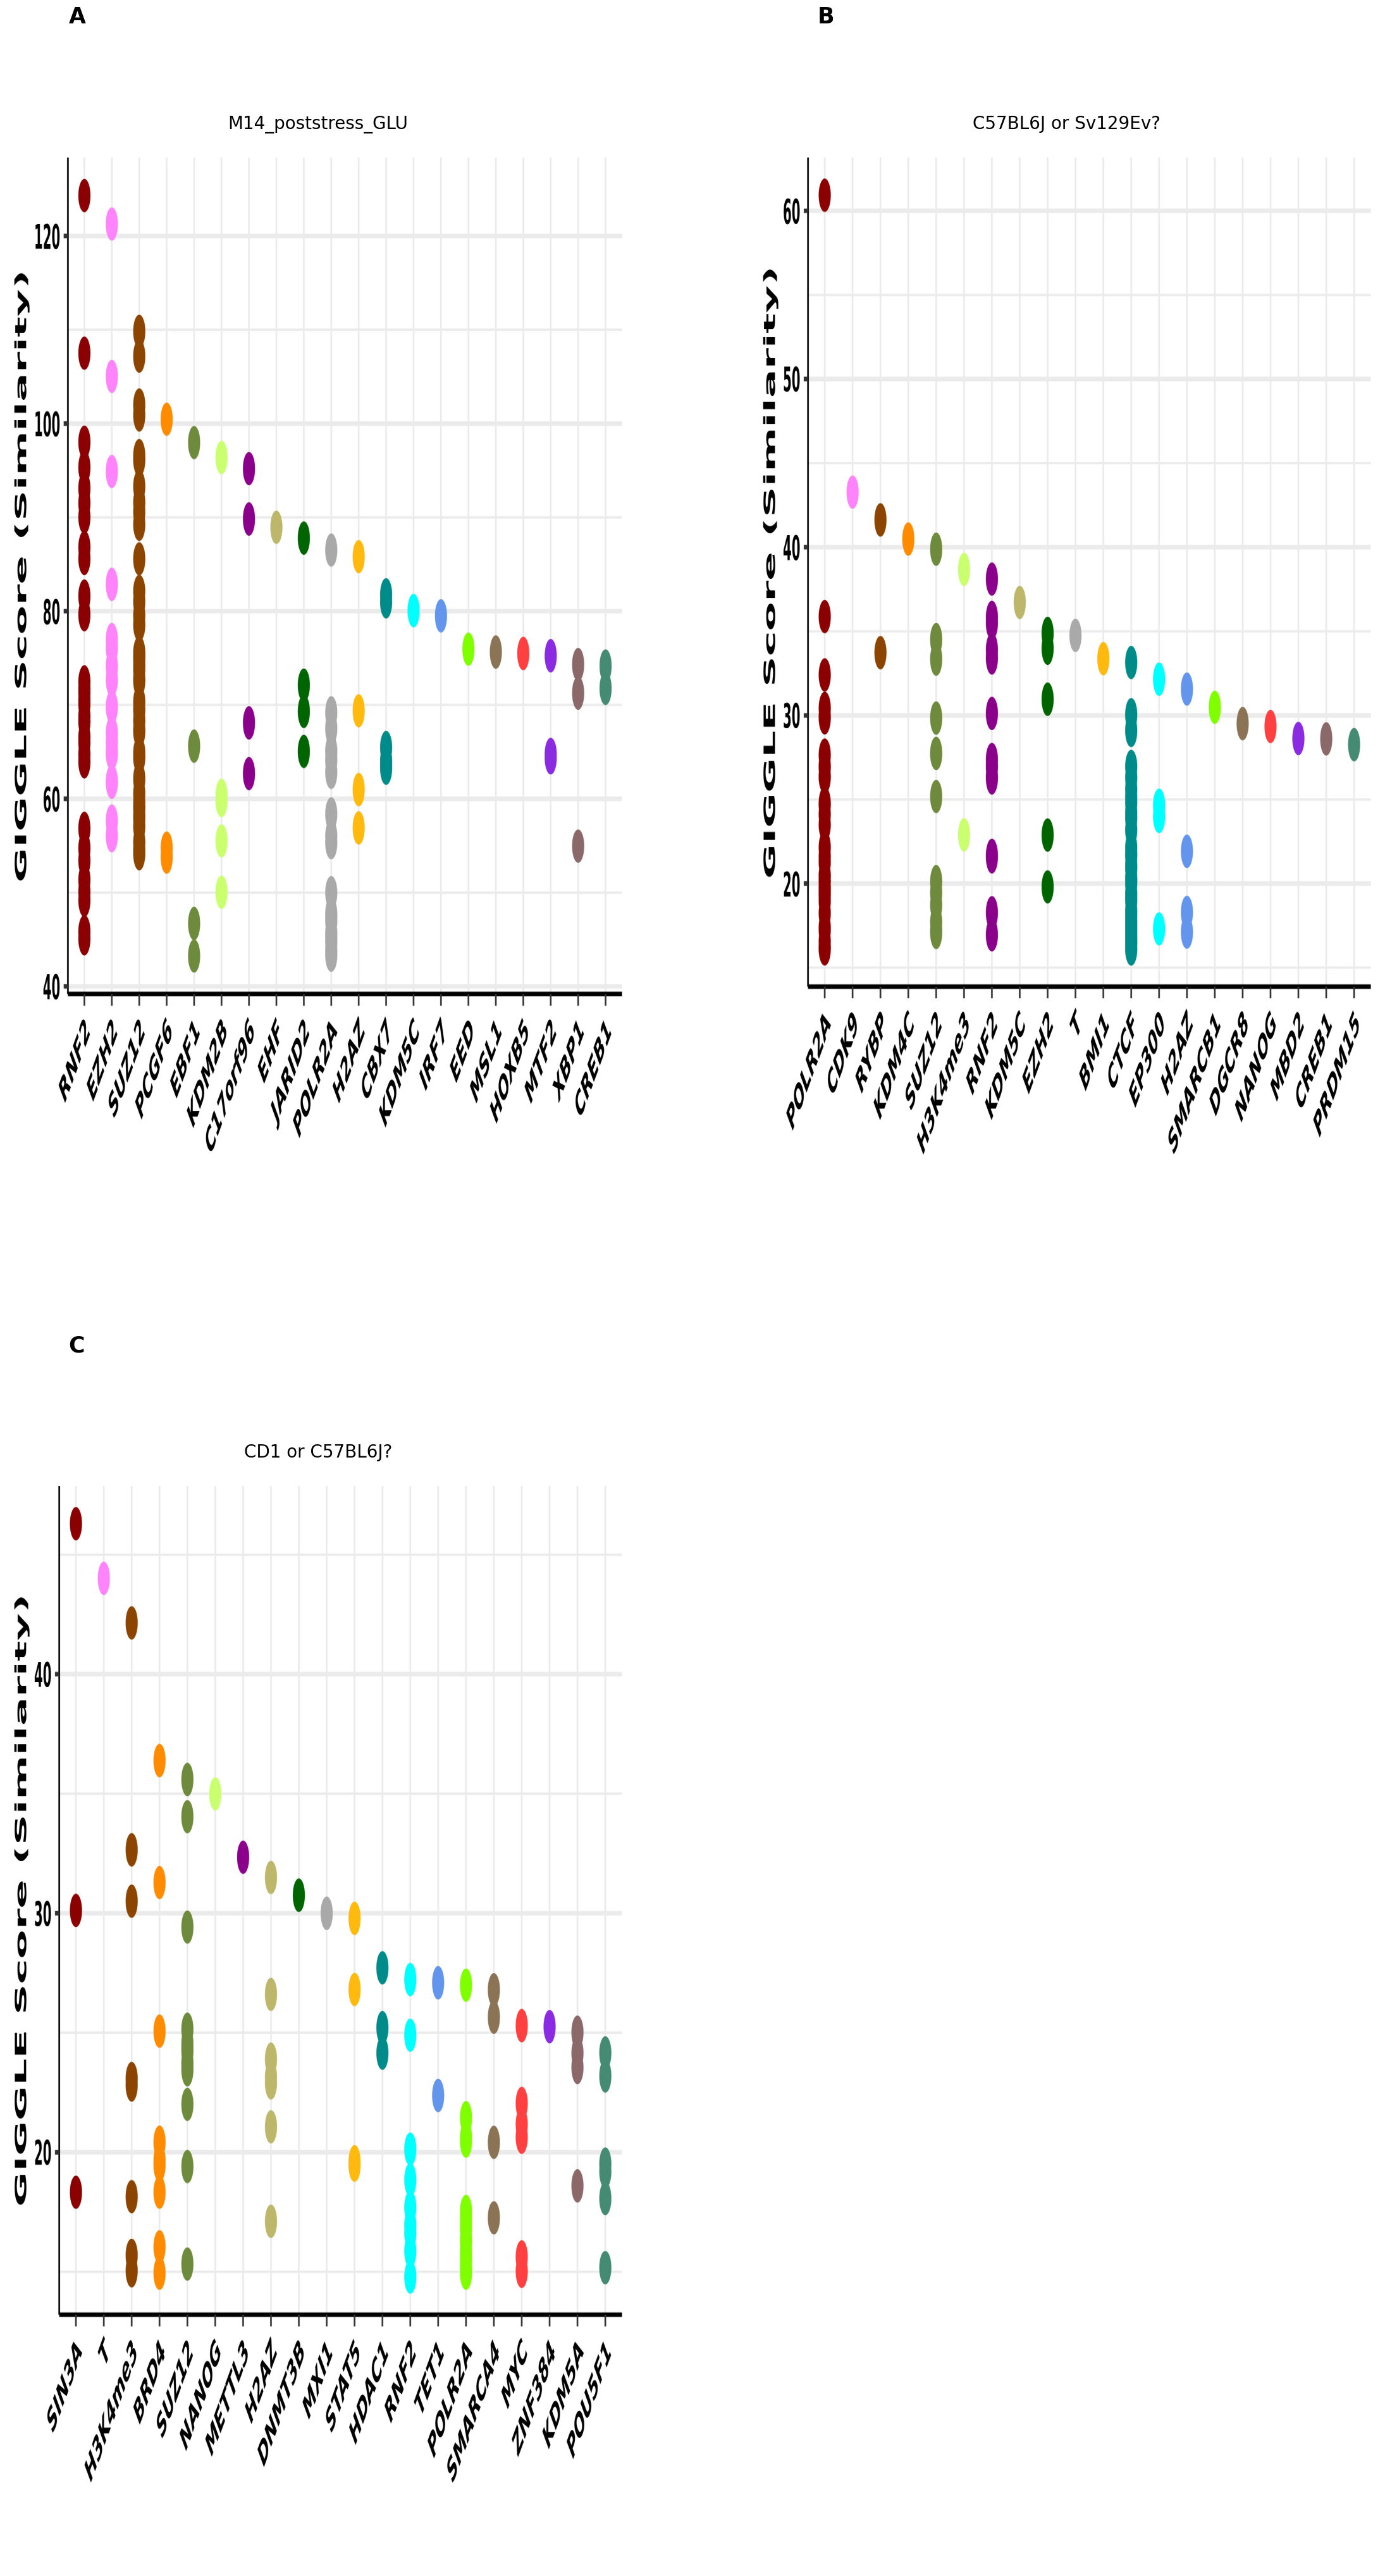

In [17]:
# get cistrome plots using unfiltered probes (so a larger set to select from)

%matplotlib inline

# this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3500 #5000 for 5/6

# generate cistrome plots by trait
get_cistrome(trait_vals_no_insig, fig_w, fig_h)